# Modélisation — détection non supervisée de fraude

Protocole rigoureux : **train interne** pour ajuster les détecteurs, **validation** pour choisir représentation et hyperparamètres, puis **test final consulté une seule fois**. La cible n'entre jamais dans les modèles; elle sert uniquement aux métriques.

In [1]:
import sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split

def find_root(p):
    for q in [p, *p.parents]:
        if (q/'data'/'raw'/'fraud_oracle.csv').exists(): return q
    raise RuntimeError('Racine introuvable')
ROOT=find_root(Path.cwd()); OUTPUTS=ROOT/'data'/'sorties'; RANDOM_STATE=42; SEEDS=range(3)
warnings.filterwarnings('ignore'); sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
BLUE, CORAL, TEAL='#2563EB','#F43F5E','#0D9488'; COLORS={'Isolation Forest':BLUE,'LOF':CORAL,'One-Class SVM':TEAL}
def load(name): return pd.read_csv(OUTPUTS/f'{name}.csv')
print('Racine :',ROOT)

Racine : C:\Users\hamid\Downloads\Projet_ML_iForest


## 1. Chargement et séparation train interne / validation / test final

In [2]:
y_train=load('y_train')['FraudFound_P']; y_test=load('y_test')['FraudFound_P']
X_train=load('X_train_freq_scaled'); X_test=load('X_test_freq_scaled')
idx=np.arange(len(y_train)); fit_idx,val_idx=train_test_split(idx,test_size=.25,stratify=y_train,random_state=RANDOM_STATE)
print(f'Fit interne: {len(fit_idx):,} | validation: {len(val_idx):,} | test final: {len(y_test):,}')
print(f'Taux fraude: {y_train.iloc[fit_idx].mean():.2%} / {y_train.iloc[val_idx].mean():.2%} / {y_test.mean():.2%}')

Fit interne: 8,673 | validation: 2,892 | test final: 3,855
Taux fraude: 5.98% / 5.98% / 5.99%


## 2. Fonctions d'évaluation

In [3]:
def scores(model,Xfit,Xeval): model.fit(Xfit); return -model.score_samples(Xeval)
def at_k(y,s,k):
    hit=y.to_numpy()[np.argsort(-s)[:k]].sum(); p=hit/k
    return p,hit/y.sum(),p/y.mean()
def metrics(y,s):
    out={'ROC_AUC':roc_auc_score(y,s),'PR_AUC':average_precision_score(y,s)}
    for frac in [.01,.02,.05,.10]:
        k=max(1,int(frac*len(y))); p,r,l=at_k(y,s,k)
        out[f'precision_top_{int(frac*100)}pct']=p; out[f'recall_top_{int(frac*100)}pct']=r; out[f'lift_top_{int(frac*100)}pct']=l
    return out

## 3. Représentation d'entrée

In [4]:
BEST_REP='freq_scaled'
Xall=X_train
print('Représentation utilisée : encodage fréquentiel + standardisation (retenue au notebook 02)')
print('Dimensions :', X_train.shape, X_test.shape)

Représentation utilisée : encodage fréquentiel + standardisation (retenue au notebook 02)
Dimensions : (11565, 37) (3855, 37)


**Lecture.** La représentation d'entrée (encodage fréquentiel standardisé) a été retenue lors du feature engineering ; ce notebook la charge telle quelle. La validation interne servira uniquement au réglage des hyperparamètres (§4-5), sans jamais consulter le test.

## 4. Sensibilité et choix des hyperparamètres sur validation

,max_samples,n_estimators,ROC_AUC_val,std
2,128,100,0.5344,0.0039
3,128,200,0.5332,0.0033
6,512,100,0.5324,0.0032
4,256,100,0.5319,0.0059
7,512,200,0.5297,0.0018
5,256,200,0.5294,0.0044
0,64,100,0.5180,0.0108
1,64,200,0.5137,0.0052


Choix validation : 128 100


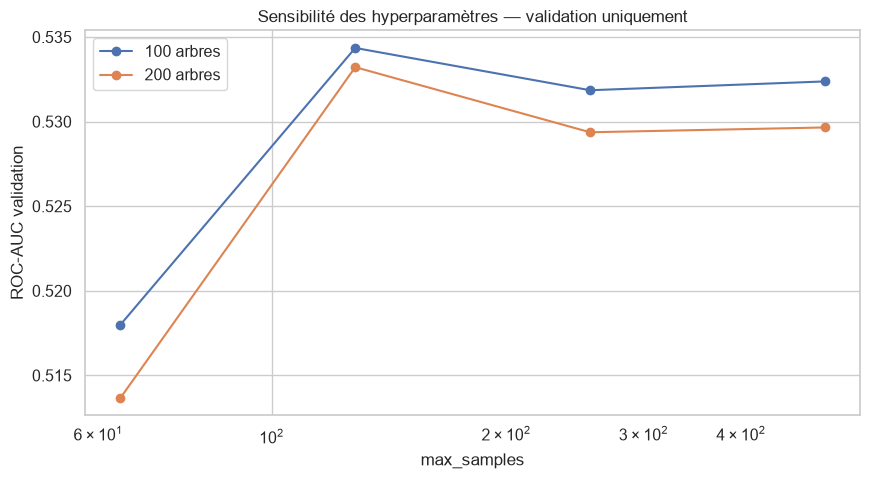

In [5]:
Xall=X_train; psis=[64,128,256,512]; trees=[100,200]; rows=[]
for psi in psis:
 for t in trees:
  auc=[]
  for seed in SEEDS:
   s=scores(IsolationForest(n_estimators=t,max_samples=psi,random_state=seed),Xall.iloc[fit_idx],Xall.iloc[val_idx])
   auc.append(roc_auc_score(y_train.iloc[val_idx],s))
  rows.append({'max_samples':psi,'n_estimators':t,'ROC_AUC_val':np.mean(auc),'std':np.std(auc)})
tuning=pd.DataFrame(rows); display(tuning.sort_values('ROC_AUC_val',ascending=False).head(10).round(4))
best=tuning.sort_values(['ROC_AUC_val','n_estimators'],ascending=[False,True]).iloc[0]
BEST_PSI=int(best.max_samples); BEST_T=int(best.n_estimators); print('Choix validation :',BEST_PSI,BEST_T)
fig,ax=plt.subplots(figsize=(10,5))
for t,g in tuning.groupby('n_estimators'): ax.plot(g.max_samples,g.ROC_AUC_val,marker='o',label=f'{t} arbres')
ax.set(xscale='log',xlabel='max_samples',ylabel='ROC-AUC validation',title='Sensibilité des hyperparamètres — validation uniquement'); ax.legend(); plt.show()

## 5. Ablation de `Year` sur validation

In [6]:
def drop_year(X): return X.drop(columns=['Year'],errors='ignore')
ab=[]
for keep in [True,False]:
 X=Xall if keep else drop_year(Xall); vals=[]
 for seed in SEEDS:
  s=scores(IsolationForest(n_estimators=BEST_T,max_samples=BEST_PSI,random_state=seed),X.iloc[fit_idx],X.iloc[val_idx]); vals.append(roc_auc_score(y_train.iloc[val_idx],s))
 ab.append({'Year incluse':keep,'ROC_AUC_val':np.mean(vals),'std':np.std(vals)})
ablation=pd.DataFrame(ab); display(ablation.round(4)); KEEP_YEAR=bool(ablation.sort_values('ROC_AUC_val',ascending=False).iloc[0]['Year incluse']); print('Year conservée :',KEEP_YEAR)

,Year incluse,ROC_AUC_val,std
0,True,0.5344,0.0039
1,False,0.5333,0.0006


Year conservée : True


## 6. Évaluation finale — test consulté une seule fois

In [7]:
Xtr,Xte=X_train.copy(),X_test.copy();
if not KEEP_YEAR: Xtr,Xte=drop_year(Xtr),drop_year(Xte)
final_scores={
'Isolation Forest':scores(IsolationForest(n_estimators=BEST_T,max_samples=BEST_PSI,random_state=RANDOM_STATE),Xtr,Xte),
'LOF':scores(LocalOutlierFactor(n_neighbors=20,novelty=True),X_train,X_test),
'One-Class SVM':scores(OneClassSVM(kernel='rbf',gamma='scale',nu=.06),X_train,X_test)}
final=pd.DataFrame({k:metrics(y_test.reset_index(drop=True),v) for k,v in final_scores.items()}).T
display(final.round(4)); print('Référence aléatoire: ROC-AUC=0.5, PR-AUC=',round(y_test.mean(),4))

,ROC_AUC,PR_AUC,precision_top_1pct,recall_top_1pct,lift_top_1pct,precision_top_2pct,recall_top_2pct,lift_top_2pct,precision_top_5pct,recall_top_5pct,lift_top_5pct,precision_top_10pct,recall_top_10pct,lift_top_10pct
Isolation Forest,0.5207,0.0675,0.0526,0.0087,0.8783,0.0519,0.0173,0.8669,0.0521,0.0433,0.8692,0.0623,0.1039,1.0403
LOF,0.5537,0.0729,0.0263,0.0043,0.4392,0.0779,0.0260,1.3004,0.0833,0.0693,1.3907,0.0883,0.1472,1.4738
One-Class SVM,0.5405,0.0681,0.0789,0.0130,1.3175,0.0649,0.0216,1.0837,0.0625,0.0519,1.0430,0.0727,0.1212,1.2137


Référence aléatoire: ROC-AUC=0.5, PR-AUC= 0.0599


## 7. Courbes et budgets d'investigation

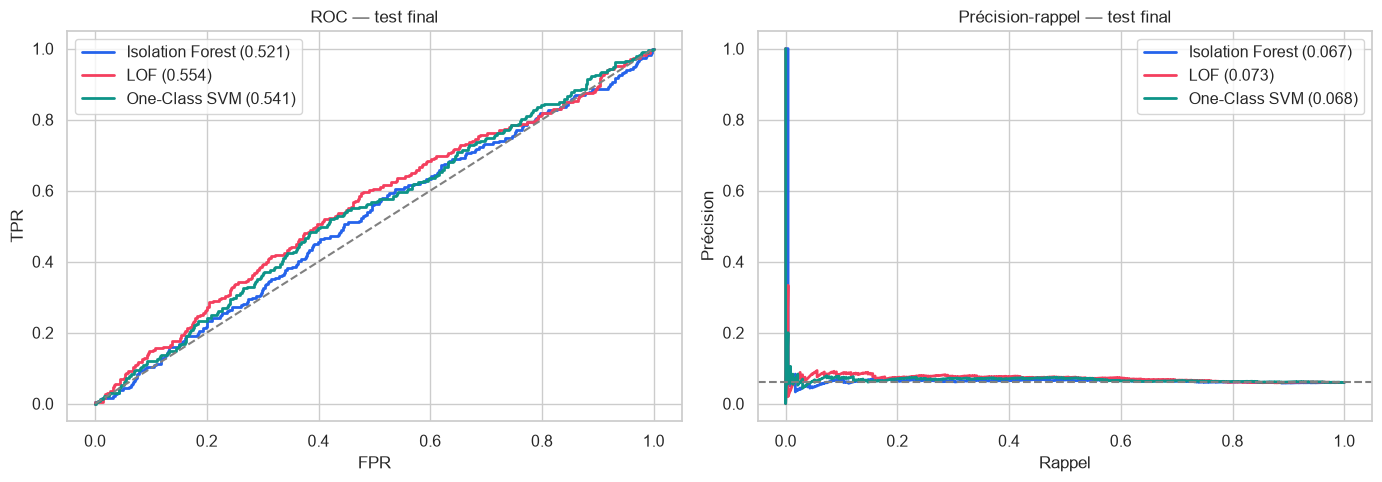

,precision_top_1pct,recall_top_1pct,lift_top_1pct,precision_top_2pct,recall_top_2pct,lift_top_2pct,precision_top_5pct,recall_top_5pct,lift_top_5pct,precision_top_10pct,recall_top_10pct,lift_top_10pct
Isolation Forest,0.0526,0.0087,0.8783,0.0519,0.0173,0.8669,0.0521,0.0433,0.8692,0.0623,0.1039,1.0403
LOF,0.0263,0.0043,0.4392,0.0779,0.0260,1.3004,0.0833,0.0693,1.3907,0.0883,0.1472,1.4738
One-Class SVM,0.0789,0.0130,1.3175,0.0649,0.0216,1.0837,0.0625,0.0519,1.0430,0.0727,0.1212,1.2137


In [8]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for name,s in final_scores.items():
 fpr,tpr,_=roc_curve(y_test,s); axes[0].plot(fpr,tpr,lw=2,color=COLORS[name],label=f'{name} ({roc_auc_score(y_test,s):.3f})')
 p,r,_=precision_recall_curve(y_test,s); axes[1].plot(r,p,lw=2,color=COLORS[name],label=f'{name} ({average_precision_score(y_test,s):.3f})')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[1].axhline(y_test.mean(),ls='--',color='gray')
axes[0].set(title='ROC — test final',xlabel='FPR',ylabel='TPR'); axes[1].set(title='Précision-rappel — test final',xlabel='Rappel',ylabel='Précision')
for ax in axes: ax.legend();
plt.tight_layout(); plt.show()
budget=final[[c for c in final.columns if 'top_' in c]]; display(budget.round(4))

## 8. Conclusion critique

Le protocole sépare désormais sélection et évaluation finale. Si les scores restent proches de l'aléatoire — surtout temporellement — la conclusion correcte est que les fraudes de `carclaims` ne sont pas suffisamment des anomalies globales « rares et différentes » dans cette représentation. Ce résultat négatif est informatif : Isolation Forest peut servir à prioriser des dossiers atypiques, mais ne remplace pas un modèle supervisé de fraude. Les seuils opérationnels doivent être définis par budget d'investigation, jamais à partir du nombre réel de fraudes du test.